In [1]:
import pandas as pd

df = pd.read_csv('data/LeagueofLegends.csv')


In [2]:
# Show first 5 rows
df.head()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,...,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,...,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,...,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,...,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,...,3,0,0,1,0,86,11,201,122,18


In [3]:
# Check shape (rows, columns)
df.shape

(51490, 61)

In [4]:
# Get quick info — column names, types, missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51490 entries, 0 to 51489
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gameId              51490 non-null  int64
 1   creationTime        51490 non-null  int64
 2   gameDuration        51490 non-null  int64
 3   seasonId            51490 non-null  int64
 4   winner              51490 non-null  int64
 5   firstBlood          51490 non-null  int64
 6   firstTower          51490 non-null  int64
 7   firstInhibitor      51490 non-null  int64
 8   firstBaron          51490 non-null  int64
 9   firstDragon         51490 non-null  int64
 10  firstRiftHerald     51490 non-null  int64
 11  t1_champ1id         51490 non-null  int64
 12  t1_champ1_sum1      51490 non-null  int64
 13  t1_champ1_sum2      51490 non-null  int64
 14  t1_champ2id         51490 non-null  int64
 15  t1_champ2_sum1      51490 non-null  int64
 16  t1_champ2_sum2      51490 non-null  int6

In [5]:
# Quick statistical summary
df.describe()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,5.149000e+04,5.149000e+04,51490.000000,51490.0,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,...,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000
mean,3.306223e+09,1.502926e+12,1832.362808,9.0,1.493552,1.471295,1.450631,1.308487,0.926510,1.442804,...,5.549466,0.985084,0.414547,1.404370,0.240105,108.216294,107.910216,108.690581,108.626044,108.066576
std,2.946096e+07,1.978026e+09,512.017696,0.0,0.499963,0.520326,0.542848,0.676097,0.841424,0.569579,...,3.860989,1.256284,0.613768,1.224492,0.427151,102.551787,102.870710,102.592145,103.346952,102.756149
min,3.214824e+09,1.496892e+12,190.000000,9.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,3.292218e+09,1.502021e+12,1531.000000,9.0,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,38.000000,37.000000,38.000000,38.000000,38.000000
50%,3.320021e+09,1.503844e+12,1833.000000,9.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,6.000000,0.000000,0.000000,1.000000,0.000000,90.000000,90.000000,90.000000,90.000000,90.000000
75%,3.327099e+09,1.504352e+12,2148.000000,9.0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,9.000000,2.000000,1.000000,2.000000,0.000000,141.000000,141.000000,141.000000,141.000000,141.000000
max,3.331833e+09,1.504707e+12,4728.000000,9.0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,11.000000,10.000000,4.000000,6.000000,1.000000,516.000000,516.000000,516.000000,516.000000,516.000000


In [6]:
df['winner'].value_counts()

winner
1    26077
2    25413
Name: count, dtype: int64

In [7]:
features = [
    't1_towerKills', 't1_inhibitorKills', 't1_baronKills', 
    't1_dragonKills', 't1_riftHeraldKills',
    't2_towerKills', 't2_inhibitorKills', 't2_baronKills', 
    't2_dragonKills', 't2_riftHeraldKills'
]

target = 'winner'

In [8]:
df = df.dropna(subset=features + [target])

X = df[features].copy()
y = (df[target] == 1).astype(int)

In [9]:
X.info()
y.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51490 entries, 0 to 51489
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   t1_towerKills       51490 non-null  int64
 1   t1_inhibitorKills   51490 non-null  int64
 2   t1_baronKills       51490 non-null  int64
 3   t1_dragonKills      51490 non-null  int64
 4   t1_riftHeraldKills  51490 non-null  int64
 5   t2_towerKills       51490 non-null  int64
 6   t2_inhibitorKills   51490 non-null  int64
 7   t2_baronKills       51490 non-null  int64
 8   t2_dragonKills      51490 non-null  int64
 9   t2_riftHeraldKills  51490 non-null  int64
dtypes: int64(10)
memory usage: 3.9 MB


winner
1    26077
0    25413
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look better
sns.set(style="whitegrid", palette="pastel")

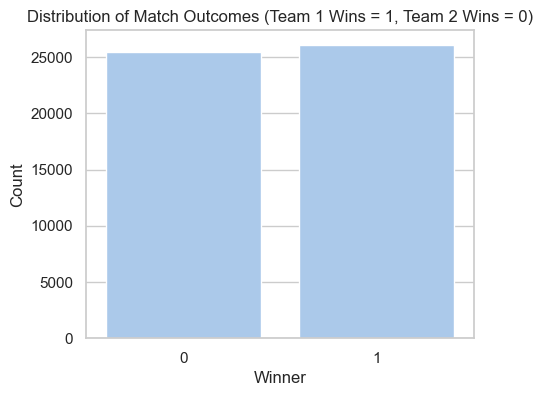

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Distribution of Match Outcomes (Team 1 Wins = 1, Team 2 Wins = 0)")
plt.xlabel("Winner")
plt.ylabel("Count")
plt.show()

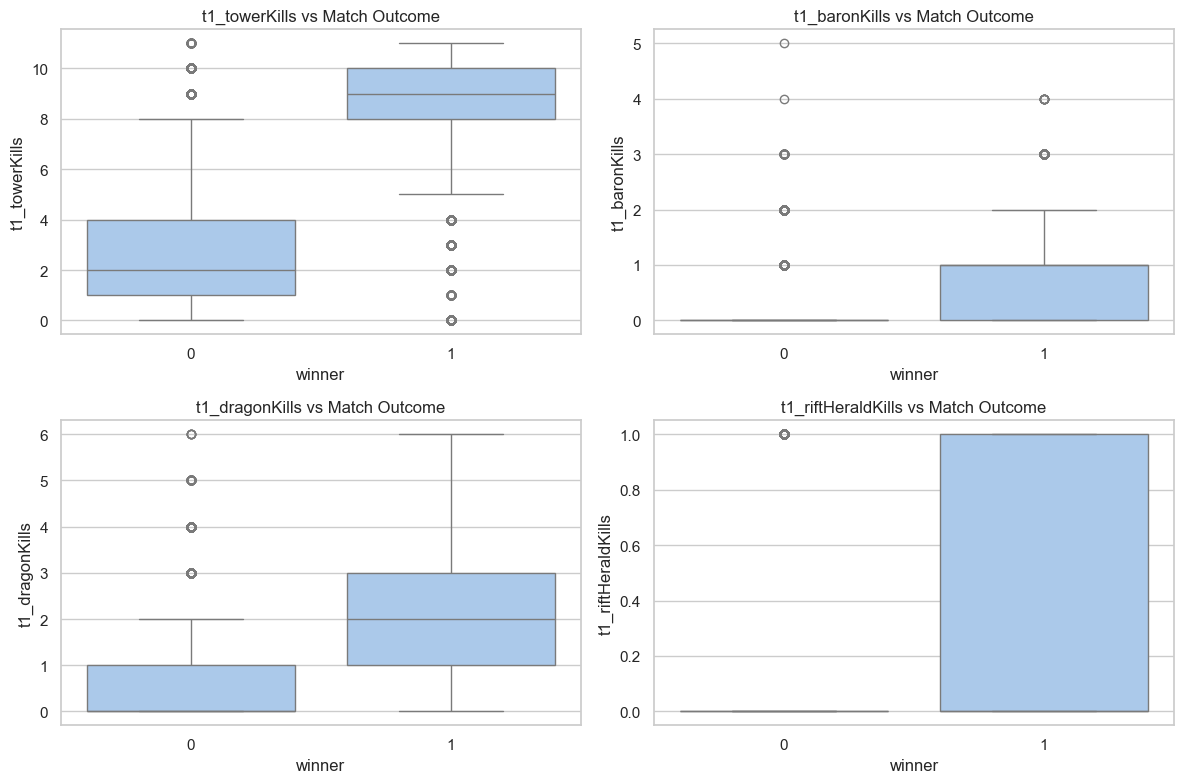

In [12]:
cols_to_plot = ['t1_towerKills', 't1_baronKills', 't1_dragonKills', 't1_riftHeraldKills']

plt.figure(figsize=(12,8))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Match Outcome")
plt.tight_layout()
plt.show()

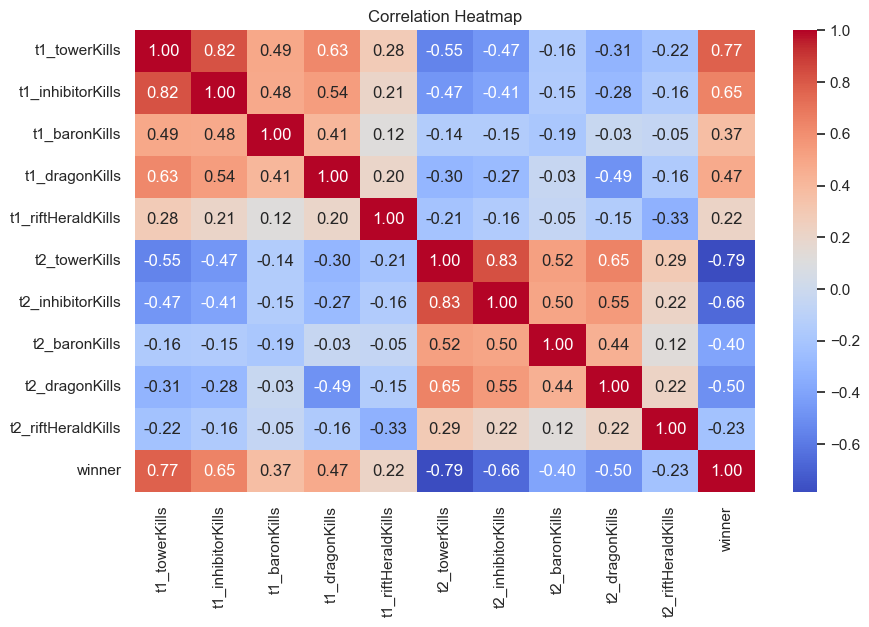

In [13]:
# Combine features and target for correlation analysis
df_corr = X.copy()
df_corr['winner'] = y

plt.figure(figsize=(10,6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df_corr.corr()

,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,winner
t1_towerKills,1.000000,0.824471,0.490723,0.626743,0.283925,-0.549123,-0.469600,-0.158556,-0.313789,-0.224888,0.771541
t1_inhibitorKills,0.824471,1.000000,0.481606,0.538469,0.210728,-0.467867,-0.408924,-0.153026,-0.279089,-0.164355,0.649405
t1_baronKills,0.490723,0.481606,1.000000,0.409380,0.119870,-0.144271,-0.146382,-0.189526,-0.027525,-0.053148,0.369472
t1_dragonKills,0.626743,0.538469,0.409380,1.000000,0.203930,-0.303139,-0.269714,-0.033048,-0.486093,-0.159509,0.472483
t1_riftHeraldKills,0.283925,0.210728,0.119870,0.203930,1.000000,-0.214717,-0.157812,-0.053136,-0.149586,-0.325805,0.218066
t2_towerKills,-0.549123,-0.467867,-0.144271,-0.303139,-0.214717,1.000000,0.825834,0.522166,0.648020,0.290283,-0.785813
t2_inhibitorKills,-0.469600,-0.408924,-0.146382,-0.269714,-0.157812,0.825834,1.000000,0.499613,0.548134,0.216553,-0.660452
t2_baronKills,-0.158556,-0.153026,-0.189526,-0.033048,-0.053136,0.522166,0.499613,1.000000,0.444655,0.124451,-0.399249
t2_dragonKills,-0.313789,-0.279089,-0.027525,-0.486093,-0.149586,0.648020,0.548134,0.444655,1.000000,0.220556,-0.497206
t2_riftHeraldKills,-0.224888,-0.164355,-0.053148,-0.159509,-0.325805,0.290283,0.216553,0.124451,0.220556,1.000000,-0.226102


In [15]:
X['tower_diff'] = X['t1_towerKills'] - X['t2_towerKills']
X['inhibitor_diff'] = X['t1_inhibitorKills'] - X['t2_inhibitorKills']
X['baron_diff'] = X['t1_baronKills'] - X['t2_baronKills']
X['dragon_diff'] = X['t1_dragonKills'] - X['t2_dragonKills']
X['herald_diff'] = X['t1_riftHeraldKills'] - X['t2_riftHeraldKills']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42,
    max_depth=8
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9632938434647504

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      5067
           1       0.95      0.98      0.96      5231

    accuracy                           0.96     10298
   macro avg       0.96      0.96      0.96     10298
weighted avg       0.96      0.96      0.96     10298



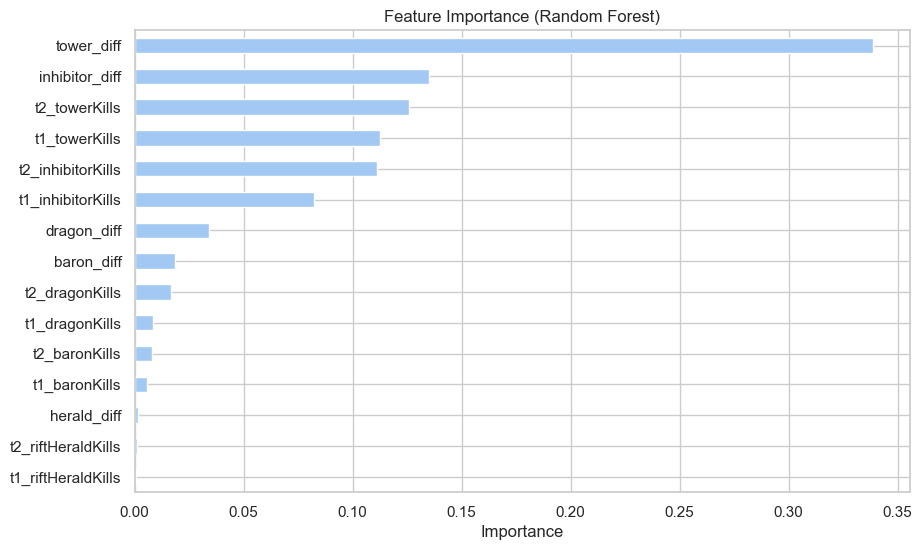

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()


In [24]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1, gamma='scale'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [26]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    results[name] = cv_results
    print(f"{name}: {cv_results.mean():.4f} ± {cv_results.std():.4f}")

Logistic Regression: 0.9597 ± 0.0019
Decision Tree: 0.9537 ± 0.0009
Random Forest: 0.9634 ± 0.0013
K-Nearest Neighbors: 0.9608 ± 0.0019
SVM (RBF Kernel): 0.9621 ± 0.0015
Gradient Boosting: 0.9636 ± 0.0012
AdaBoost: 0.9594 ± 0.0011


C:\Users\RWIK\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\RWIK\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\RWIK\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\RWIK\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,

XGBoost: 0.9621 ± 0.0013


C:\Users\RWIK\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42
)

final_model.fit(X, y)

C:\Users\RWIK\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:45:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
import joblib

joblib.dump(final_model, 'models/xgb_lol_model.pkl')
print("✅ Model saved successfully!")

✅ Model saved successfully!
